# agentv10_reflection_loop — Generate, Critique, Revise

This version introduces a reflection loop.

Graph:

```text
START → draft_answer → critic
                        ├── revise_answer → critic
                        └── final_answer → END
```

The agent generates an answer, critiques it, revises if needed, and stops when the quality is good enough or the revision limit is reached.


## 1. Install dependencies

```bash
pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter
```


In [1]:
# Optional: uncomment in a fresh environment.
# %pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter


## 2. Load environment variables


In [2]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))


OpenAI API key present: True
LangSmith tracing: true
LangSmith project: langgraph-playground


## 3. Define constants and state

The loop needs a stopping rule.

```python
PASS_SCORE = 8
MAX_REVISIONS = 2
```


In [3]:
from typing import TypedDict

MAX_REVISIONS = 2
PASS_SCORE = 8

class AgentState(TypedDict, total=False):
    input: str
    draft: str
    critique: str
    quality_score: int
    revision_count: int
    final_answer: str


## 4. Create LLM


In [4]:
from langchain_openai import ChatOpenAI

def create_llm():
    return ChatOpenAI(model="gpt-4o-mini", temperature=0)


## 5. Draft answer node

This node creates the first answer.


In [5]:
def draft_answer_node(state: AgentState) -> AgentState:
    llm = create_llm()

    prompt = f'''
Write a concise but useful answer to the user request.

User request:
{state["input"]}

For this playground, assume the domain is EPP SLA analytics and incident analysis.
Include:
- concise summary
- likely cause if applicable
- recommended next action
'''

    response = llm.invoke(prompt)
    return {
        "draft": response.content,
        "revision_count": 0,
    }


## 6. Critic response parser

The critic should return JSON, but production code should handle imperfect output.


In [6]:
import json
import re

def parse_critic_response(text: str) -> tuple[int, str]:
    try:
        parsed = json.loads(text)
        score = int(parsed.get("quality_score", 0))
        critique = str(parsed.get("critique", text))
        return max(0, min(10, score)), critique
    except Exception:
        match = re.search(r"\b([0-9]|10)\b", text)
        score = int(match.group(1)) if match else 5
        return score, text


## 7. Critic node

The critic reviews the current draft and returns:
- quality score
- critique


In [7]:
def critic_node(state: AgentState) -> AgentState:
    llm = create_llm()

    prompt = f'''
You are a strict quality critic for agent responses.

User request:
{state["input"]}

Current draft:
{state["draft"]}

Evaluate the draft on:
- correctness
- completeness
- specificity
- usefulness
- clarity
- whether it avoids unsupported claims

Return only valid JSON in this exact shape:
{{
  "quality_score": 0,
  "critique": "specific critique and missing items"
}}

Score from 0 to 10.
A score of 8 or higher means the answer is good enough.
'''

    response = llm.invoke(prompt)
    score, critique = parse_critic_response(response.content)

    return {
        "quality_score": score,
        "critique": critique,
    }


## 8. Routing after critic

This is the reflection loop decision point.


In [8]:
def route_after_critic(state: AgentState) -> str:
    if state.get("quality_score", 0) >= PASS_SCORE:
        return "final_answer"

    if state.get("revision_count", 0) >= MAX_REVISIONS:
        return "final_answer"

    return "revise_answer"


## 9. Revise answer node


In [9]:
def revise_answer_node(state: AgentState) -> AgentState:
    llm = create_llm()

    prompt = f'''
Revise the draft based on the critique.

User request:
{state["input"]}

Current draft:
{state["draft"]}

Critique:
{state["critique"]}

Produce an improved answer.
Keep it concise, specific, and actionable.
'''

    response = llm.invoke(prompt)

    return {
        "draft": response.content,
        "revision_count": state.get("revision_count", 0) + 1,
    }


## 10. Final answer node


In [10]:
def final_answer_node(state: AgentState) -> AgentState:
    return {
        "final_answer": state["draft"]
    }


## 11. Build graph


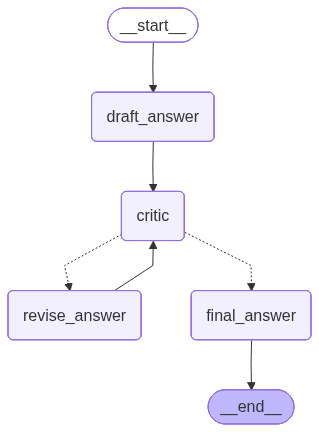

In [11]:
from langgraph.graph import START, END, StateGraph

def build_graph():
    graph_builder = StateGraph(AgentState)

    graph_builder.add_node("draft_answer", draft_answer_node)
    graph_builder.add_node("critic", critic_node)
    graph_builder.add_node("revise_answer", revise_answer_node)
    graph_builder.add_node("final_answer", final_answer_node)

    graph_builder.add_edge(START, "draft_answer")
    graph_builder.add_edge("draft_answer", "critic")

    graph_builder.add_conditional_edges(
        "critic",
        route_after_critic,
        {
            "revise_answer": "revise_answer",
            "final_answer": "final_answer",
        },
    )

    graph_builder.add_edge("revise_answer", "critic")
    graph_builder.add_edge("final_answer", END)

    return graph_builder.compile()

graph = build_graph()
graph


## 12. Visualize Mermaid graph


In [12]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	draft_answer(draft_answer)
	critic(critic)
	revise_answer(revise_answer)
	final_answer(final_answer)
	__end__([<p>__end__</p>]):::last
	__start__ --> draft_answer;
	critic -.-> final_answer;
	critic -.-> revise_answer;
	draft_answer --> critic;
	revise_answer --> critic;
	final_answer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 13. Visualize PNG graph


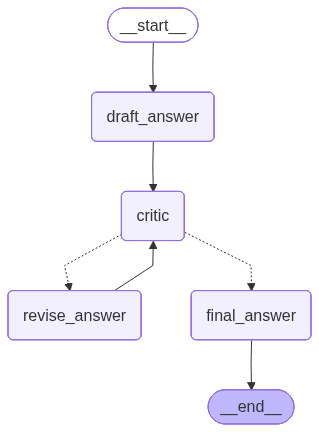

In [13]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG rendering failed.")
    print("Reason:", e)


## 14. Run reflection loop


In [14]:
result = graph.invoke(
    {
        "input": "Write an EPP SLA incident summary after release R13."
    },
    {
        "recursion_limit": 10
    },
)

print("Quality score:", result.get("quality_score"))
print("Revision count:", result.get("revision_count"))
print("Critique:", result.get("critique"))
print()
print(result["final_answer"])


Quality score: 7
Revision count: 2
Critique: The draft is mostly correct and clear, but it lacks specificity in the description of the incidents and does not provide concrete data on the types of user requests affected. Additionally, while the recommended actions are useful, they could benefit from more detail on how the performance review and optimization will be conducted. The timeline for actions is clear, but the summary could include more context about the overall impact on users and business operations. Overall, it is a solid draft but could be improved with more detailed information.

**EPP SLA Incident Summary - Release R13**

**Summary:**  
Following the deployment of Release R13, SLA metrics indicated that response times exceeded acceptable thresholds for 15% of the 200 incidents logged within the first 48 hours. The average response time increased from the standard 2 hours to 2.5 hours. The incidents primarily involved delays in processing user requests related to the new an

## 15. Inspect state fields

The final state shows the complete loop outcome.


In [15]:
result.keys()


dict_keys(['input', 'draft', 'critique', 'quality_score', 'revision_count', 'final_answer'])

## 16. Why this matters

Reflection loops are useful for quality control.

They are not free. Each critique/revision adds LLM calls, cost, and latency.

Use this pattern when final answer quality matters more than speed.


## 17. LangSmith trace

Open project:

```text
langgraph-playground
```

Inspect:
- draft answer
- critique
- quality score
- revision count
- revised answer
- final answer
